In [1]:
!pip install opencv-python numpy matplotlib

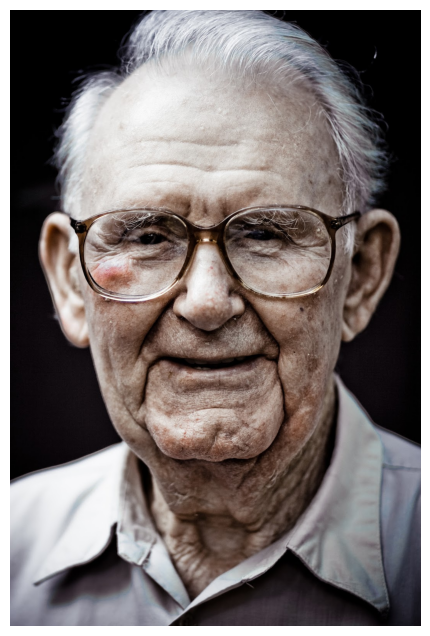

1066 1600


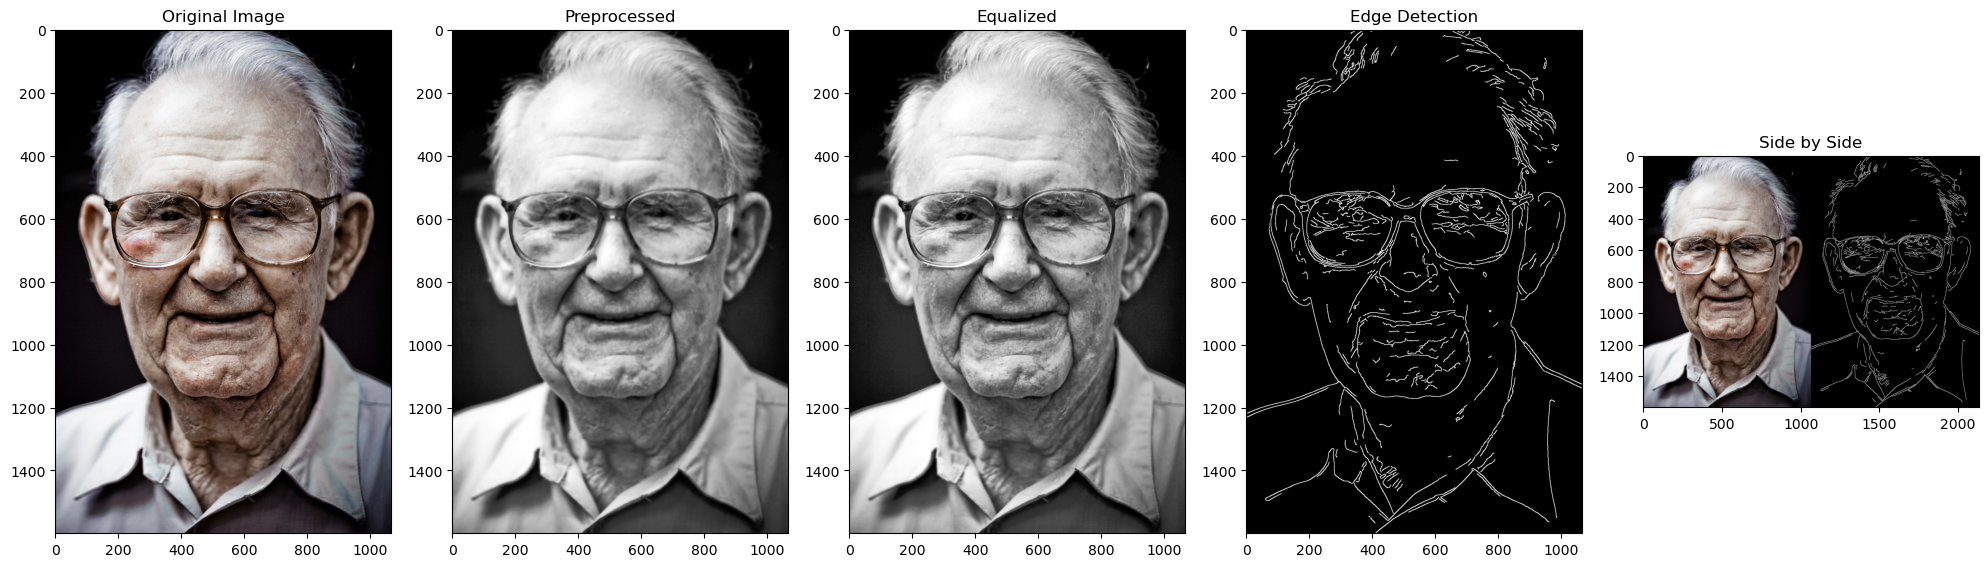

False

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Get the current directory
current_dir = os.getcwd()

# Get the parent directory (pichla folder)
parent_dir = os.path.dirname(current_dir)

# Set the path to access images from the Humans folder
img_path = os.path.join(parent_dir, 'Data', 'Humans')

# Example: Load a specific image
image_name = "1 (1).jpeg"
full_path = os.path.join(img_path, image_name)

# Read the image
img = cv2.imread(full_path)

if img is None:
    print(f"Error: Could not load image at {full_path}")
else:
    # Convert BGR to RGB for proper display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
# convertingthe img to grayscale 
    # Convert to grayscale
grayImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(grayImg, (5, 5), 0)
    
    # Apply histogram equalization to improve contrast
equalized = cv2.equalizeHist(blurred)
    
    # Apply bilateral filter to smooth while preserving edges
bilateral = cv2.bilateralFilter(equalized, 9, 75, 75)
    
    # Apply Canny edge detection with adjusted parameters
edges = cv2.Canny(bilateral, 30, 90)  # Lower thresholds to detect more edges
    
    # Optional: Dilate the edges to make them thicker
kernel = np.ones((2,2), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)
    
    # Resize edges to match original image size
edges_resized = cv2.resize(edges, (img.shape[1], img.shape[0]))
print(img.shape[1], img.shape[0])
    
    # Create side-by-side visualization
concatenated_img = np.concatenate((img, cv2.cvtColor(edges_resized, cv2.COLOR_GRAY2BGR)), axis=1)
    
    # Display all processing steps
plt.figure(figsize=(20, 10))
plt.subplot(151), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original Image')
plt.subplot(152), plt.imshow(bilateral, cmap='gray'), plt.title('Preprocessed')
plt.subplot(153), plt.imshow(equalized, cmap='gray'), plt.title('Equalized')
plt.subplot(154), plt.imshow(edges, cmap='gray'), plt.title('Edge Detection')
plt.subplot(155), plt.imshow(cv2.cvtColor(concatenated_img, cv2.COLOR_BGR2RGB)), plt.title('Side by Side')
plt.tight_layout()
plt.show()
    
    # Save the result
cv2.imwrite("./DataPreprocessing/edge_detection_result.jpg", concatenated_img)



In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

import os

# Get the current directory
current_dir = os.getcwd()

# Get the parent directory (pichla folder)
parent_dir = os.path.dirname(current_dir)

# Set the path to access images from the Humans folder
img_path = os.path.join(parent_dir, 'Data', 'Humans')
output_path = os.path.join(current_dir, 'DataPreprocessing')

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

def process_image(img):
    # Convert to grayscale
    grayImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(grayImg, (5, 5), 0)
    
    # Apply histogram equalization to improve contrast
    equalized = cv2.equalizeHist(blurred)
    
    # Apply bilateral filter to smooth while preserving edges
    bilateral = cv2.bilateralFilter(equalized, 9, 75, 75)
    
    # Apply Canny edge detection with adjusted parameters
    edges = cv2.Canny(bilateral, 20, 80)
    
    # Optional: Dilate the edges to make them thicker
    kernel = np.ones((2,2), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)
    
    # Resize edges to match original image size
    edges_resized = cv2.resize(edges, (img.shape[1], img.shape[0]))
    
    # Create side-by-side visualization
    return cv2.cvtColor(edges_resized, cv2.COLOR_GRAY2BGR)

# Process images from 1 to 1000
for i in range(1001, 6991):
    image_name = f"1 ({i}).jpg"
    full_path = os.path.join(img_path, image_name)
    
    try:
        # Read the image
        img = cv2.imread(full_path)
        
        if img is not None:
            # Process the image
            processed_edges = process_image(img)
            
            # Create side-by-side visualization
            concatenated_img = np.concatenate((img, processed_edges), axis=1)
            
            # Save the result with numbered filename
            output_filename = f"{i}_concatenated.jpg"
            output_filepath = os.path.join(output_path, output_filename)
            cv2.imwrite(output_filepath, concatenated_img)
            
            print(f"Processed and saved image {i}")
        else:
            print(f"Could not read image {image_name}")
            
    except Exception as e:
        print(f"Error processing image {image_name}: {str(e)}")

print("Processing complete!")


Processed and saved image 1001
Processed and saved image 1002
Processed and saved image 1003
Processed and saved image 1004
Processed and saved image 1005
Processed and saved image 1006
Processed and saved image 1007
Processed and saved image 1008
Processed and saved image 1009
Processed and saved image 1010
Processed and saved image 1011
Processed and saved image 1012
Processed and saved image 1013
Processed and saved image 1014
Processed and saved image 1015
Processed and saved image 1016
Processed and saved image 1017
Processed and saved image 1018
Processed and saved image 1019
Processed and saved image 1020
Processed and saved image 1021
Processed and saved image 1022
Processed and saved image 1023
Processed and saved image 1024
Processed and saved image 1025
Processed and saved image 1026
Processed and saved image 1027
Processed and saved image 1028
Processed and saved image 1029
Processed and saved image 1030
Processed and saved image 1031
Processed and saved image 1032
Processe

In [12]:
import cv2
import os
import numpy as np

# Define paths
img_path = r"C:\Users\kunal\OneDrive\CODE FOR LIFE\Human Face Sketch To RealFace\Model\Data\Humans"
output_path = r"C:\Users\kunal\OneDrive\CODE FOR LIFE\Human Face Sketch To RealFace\Model\preprocessed_dataset\processed"

# Create the output folder if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Iterate through each image in the dataset
for filename in os.listdir(img_path):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):  # Ensure valid image extensions
        # Load the image
        image_path = os.path.join(img_path, filename)
        original_image = cv2.imread(image_path)

        if original_image is None:
            print(f"Error loading image: {image_path}")
            continue

        # Convert the image to grayscale
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

        # Apply edge detection using the Canny edge detector
        edges = cv2.Canny(gray_image, 150, 250)  # Adjust threshold values as needed

        # Resize the edges image to match the height of the original image
        edges_resized = cv2.resize(edges, (original_image.shape[1], original_image.shape[0]))

        # Concatenate the original image and the edges side by side
        concatenated_image = np.concatenate((original_image, cv2.cvtColor(edges_resized, cv2.COLOR_GRAY2BGR)), axis=1)

        # Save the concatenated image
        output_filename = os.path.join(output_path, filename)
        cv2.imwrite(output_filename, concatenated_image)

print("Processing complete. Concatenated images saved in:", output_path)


KeyboardInterrupt: 

In [14]:
import cv2
import os
import numpy as np

# Define paths
img_path = r"C:\Users\kunal\OneDrive\CODE FOR LIFE\Human Face Sketch To RealFace\Model\Data\Humans"
output_path = r"C:\Users\kunal\OneDrive\CODE FOR LIFE\Human Face Sketch To RealFace\Model\preprocessed_dataset\processed"

# Create the output folder if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Iterate through each image in the dataset
for filename in os.listdir(img_path):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):  # Ensure valid image extensions
        # Load the image
        image_path = os.path.join(img_path, filename)
        original_image = cv2.imread(image_path)

        if original_image is None:
            print(f"Error loading image: {image_path}")
            continue

        # Convert the image to grayscale
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

        # Apply edge detection using the Canny edge detector
        edges = cv2.Canny(gray_image, 150, 250)  # Adjust threshold values as needed

        # Invert the edges to get a white background with black edges
        inverted_edges = cv2.bitwise_not(edges)

        # Convert to 3-channel image
        edges_colored = cv2.cvtColor(inverted_edges, cv2.COLOR_GRAY2BGR)

        # Concatenate the original image and the edges side by side
        concatenated_image = np.concatenate((original_image, edges_colored), axis=1)

        # Save the concatenated image
        output_filename = os.path.join(output_path, filename)
        cv2.imwrite(output_filename, concatenated_image)

print("Processing complete. Concatenated images saved in:", output_path)


Processing complete. Concatenated images saved in: C:\Users\kunal\OneDrive\CODE FOR LIFE\Human Face Sketch To RealFace\Model\preprocessed_dataset\processed
